# Fake News Detection — Model Building & Evaluation

Vectorize the cleaned text with TF-IDF, train 7 classifiers, compare them, run cross-validation, and tune the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from utils import evaluate_model, plot_confusion_matrix, compare_models
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/fake_news_cleaned.csv').dropna(subset=['clean_text'])
print('Shape:', df.shape)
df.head()

Shape: (6306, 2)


,clean_text,label
0,smell hillari fear daniel greenfield shillman ...,0
1,watch exact moment paul ryan commit polit suic...,0
2,kerri go pari gestur sympathi secretari state ...,1
3,berni support twitter erupt anger dnc tri warn...,0
4,battl new york primari matter primari day new ...,1


## 2. TF-IDF Vectorization & Train/Test Split

In [3]:
X_text = df['clean_text'].astype(str)
y = df['label']
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_txt)
X_test = vectorizer.transform(X_test_txt)
print('TF-IDF train matrix:', X_train.shape)
print('TF-IDF test matrix :', X_test.shape)

TF-IDF train matrix: (5044, 10000)
TF-IDF test matrix : (1262, 10000)


## 3. Train 7 Classifiers

In [4]:
results = []
models = {}


  Multinomial NB
  Accuracy    : 0.8899
  Precision   : 0.8922
  Recall      : 0.8899
  F1 Score    : 0.8897


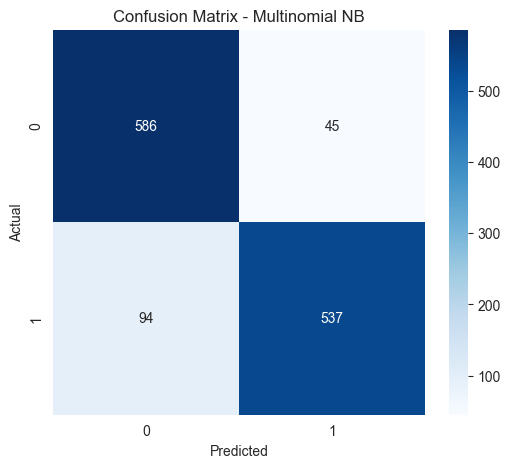

In [5]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
results.append(evaluate_model('Multinomial NB', y_test, y_pred))
models['Multinomial NB'] = mnb
plot_confusion_matrix(y_test, y_pred, 'Multinomial NB'); plt.show()


  Complement NB
  Accuracy    : 0.8899
  Precision   : 0.8922
  Recall      : 0.8899
  F1 Score    : 0.8897


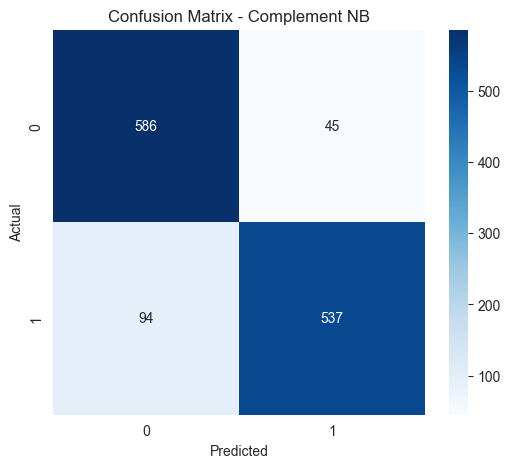

In [6]:
cnb = ComplementNB()
cnb.fit(X_train, y_train)
y_pred = cnb.predict(X_test)
results.append(evaluate_model('Complement NB', y_test, y_pred))
models['Complement NB'] = cnb
plot_confusion_matrix(y_test, y_pred, 'Complement NB'); plt.show()


  Logistic Regression
  Accuracy    : 0.9176
  Precision   : 0.9179
  Recall      : 0.9176
  F1 Score    : 0.9176


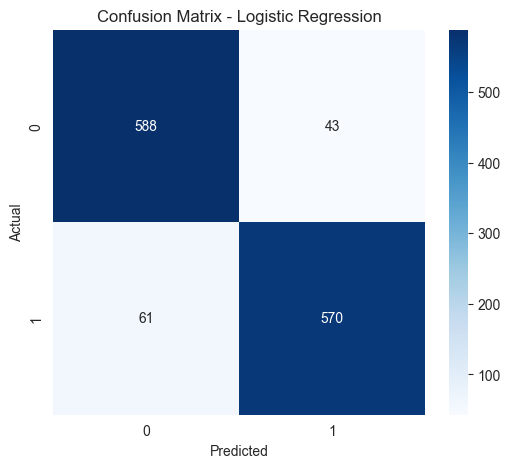

In [7]:
lr = LogisticRegression(max_iter=2000, C=1.0)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
results.append(evaluate_model('Logistic Regression', y_test, y_pred))
models['Logistic Regression'] = lr
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression'); plt.show()


  Linear SVM
  Accuracy    : 0.9287
  Precision   : 0.9287
  Recall      : 0.9287
  F1 Score    : 0.9287


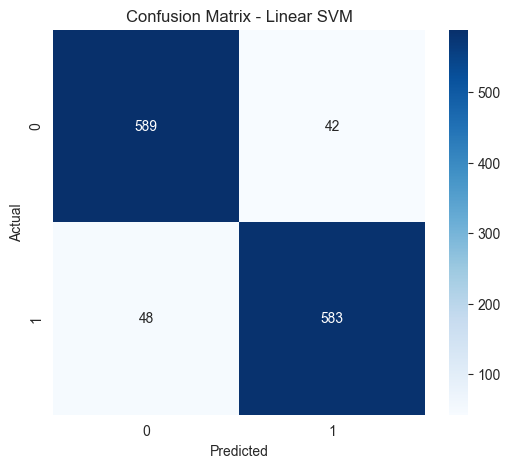

In [8]:
svm = LinearSVC(C=1.0)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
results.append(evaluate_model('Linear SVM', y_test, y_pred))
models['Linear SVM'] = svm
plot_confusion_matrix(y_test, y_pred, 'Linear SVM'); plt.show()


  Ridge Classifier
  Accuracy    : 0.9271
  Precision   : 0.9272
  Recall      : 0.9271
  F1 Score    : 0.9271


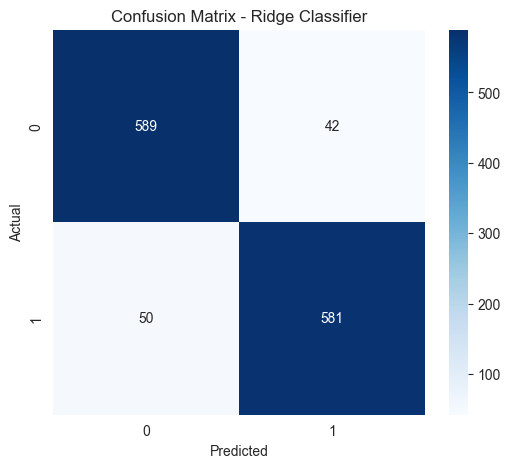

In [9]:
ridge = RidgeClassifier()
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
results.append(evaluate_model('Ridge Classifier', y_test, y_pred))
models['Ridge Classifier'] = ridge
plot_confusion_matrix(y_test, y_pred, 'Ridge Classifier'); plt.show()


  Passive Aggressive
  Accuracy    : 0.9271
  Precision   : 0.9271
  Recall      : 0.9271
  F1 Score    : 0.9271


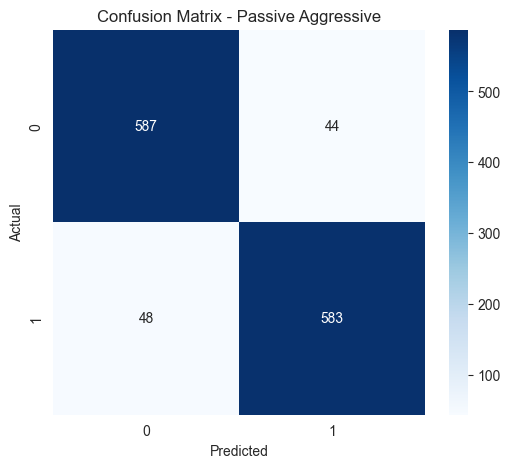

In [10]:
pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pac.fit(X_train, y_train)
y_pred = pac.predict(X_test)
results.append(evaluate_model('Passive Aggressive', y_test, y_pred))
models['Passive Aggressive'] = pac
plot_confusion_matrix(y_test, y_pred, 'Passive Aggressive'); plt.show()


  Random Forest
  Accuracy    : 0.9002
  Precision   : 0.9016
  Recall      : 0.9002
  F1 Score    : 0.9001


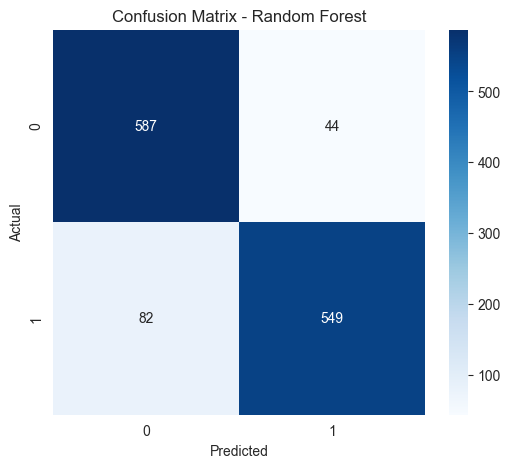

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = rf
plot_confusion_matrix(y_test, y_pred, 'Random Forest'); plt.show()

## 4. Model Comparison

In [12]:
comparison = compare_models(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.928685,0.928723,0.928685,0.928683
1,Passive Aggressive,0.927100,0.927117,0.927100,0.927099
2,Ridge Classifier,0.927100,0.927169,0.927100,0.927097
3,Logistic Regression,0.917591,0.917931,0.917591,0.917574
4,Random Forest,0.900158,0.901615,0.900158,0.900068
5,Multinomial NB,0.889857,0.892223,0.889857,0.889691
6,Complement NB,0.889857,0.892223,0.889857,0.889691


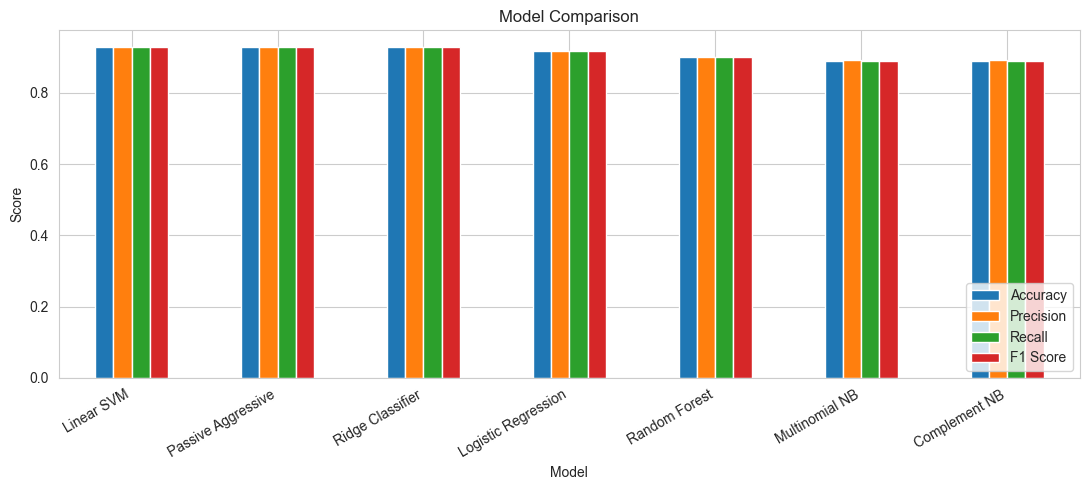

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison'); ax.set_ylabel('Score')
plt.xticks(rotation=30, ha='right'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 5. Top Predictive Words (best linear model)

In [14]:
best_linear = models.get('Logistic Regression')
feature_names = np.array(vectorizer.get_feature_names_out())
if best_linear is not None and hasattr(best_linear, 'coef_'):
    coefs = best_linear.coef_
    if coefs.shape[0] == 1:
        top_pos = feature_names[np.argsort(coefs[0])[-15:]]
        top_neg = feature_names[np.argsort(coefs[0])[:15]]
        print('Words pushing toward the positive class:'); print(list(top_pos))
        print('\nWords pushing toward the negative class:'); print(list(top_neg))
    else:
        for ci in range(min(coefs.shape[0], 4)):
            top = feature_names[np.argsort(coefs[ci])[-12:]]
            print(f'Class {ci} top words:', list(top))

Words pushing toward the positive class:
['islam state', 'tuesday', 'fox news', 'sander', 'sen', 'conserv', 'presid', 'say', 'cruz', 'candid', 'debat', 'obama', 'gop', 'republican', 'said']

Words pushing toward the negative class:
['octob', 'articl', 'novemb', 'share', 'us', 'hillari', 'sourc', 'russia', 'elect', 'post', 'wikileak', 'oct', 'email', 'via', 'corrupt']


## 6. 5-Fold Cross-Validation

In [15]:
X_all = vectorizer.fit_transform(X_text)
cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_all, y, cv=5, scoring='f1_weighted', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:22s} mean F1 = {scores.mean():.4f} (+/- {scores.std():.4f})')

Multinomial NB         mean F1 = 0.8949 (+/- 0.0036)


Complement NB          mean F1 = 0.8951 (+/- 0.0036)


Logistic Regression    mean F1 = 0.9245 (+/- 0.0060)


Linear SVM             mean F1 = 0.9415 (+/- 0.0034)


Ridge Classifier       mean F1 = 0.9391 (+/- 0.0024)


Passive Aggressive     mean F1 = 0.9410 (+/- 0.0043)


Random Forest          mean F1 = 0.9044 (+/- 0.0050)


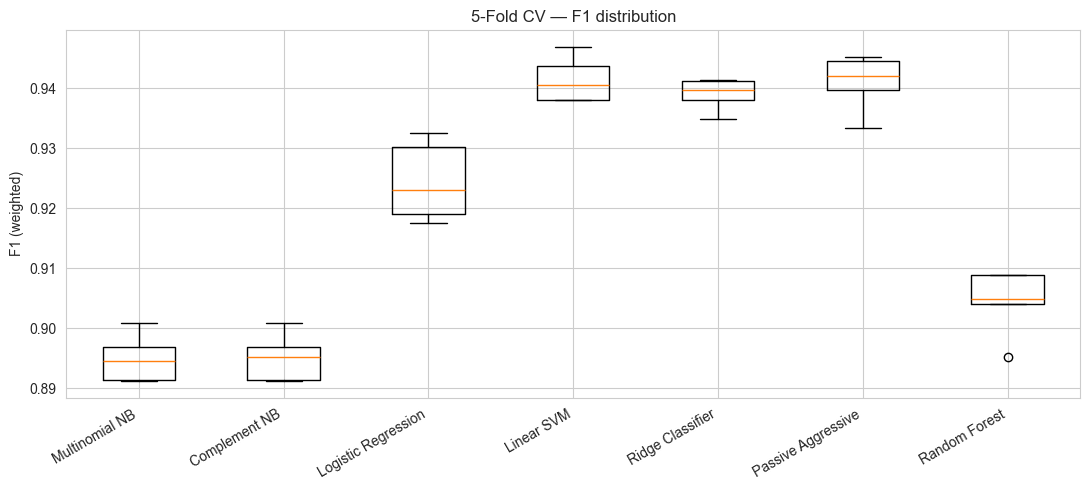

In [16]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('F1 (weighted)')
plt.title('5-Fold CV — F1 distribution'); plt.tight_layout(); plt.show()

## 7. Hyperparameter Tuning — Best Performer

Best params: {'clf__C': 10.0, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.9332



  Logistic Regression (Tuned)
  Accuracy    : 0.9295
  Precision   : 0.9295
  Recall      : 0.9295
  F1 Score    : 0.9295


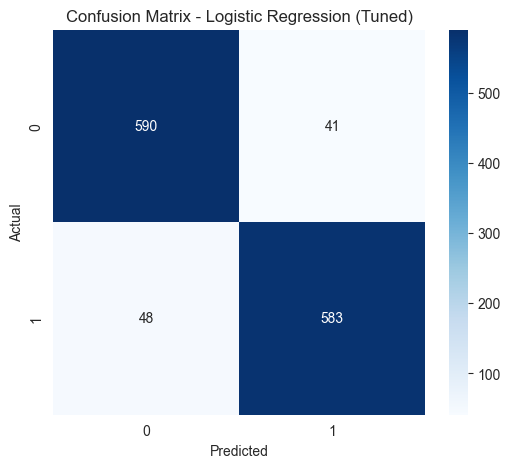

In [17]:
# Tune Logistic Regression over C and TF-IDF ngram range via a small grid
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, max_features=10000)),
    ('clf', LogisticRegression(max_iter=2000)),
])
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0],
}
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=0)
grid.fit(X_train_txt, y_train)
print('Best params:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test_txt)
tuned_metrics = evaluate_model('Logistic Regression (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression (Tuned)'); plt.show()

## 8. Sample Predictions

In [18]:
sample_idx = X_test_txt.index[:6]
best_model = models[comparison.iloc[0]['Model']]
sample_pred = best_model.predict(vectorizer.transform(X_test_txt.loc[sample_idx]))
out = pd.DataFrame({
    'text_excerpt': X_test_txt.loc[sample_idx].str.slice(0, 80).values,
    'predicted': sample_pred,
    'actual': y_test.loc[sample_idx].values,
})
out

,text_excerpt,predicted,actual
0,trump impend nomin mean time third parti donal...,0,1
1,studi run link extend lifespan brain repair st...,0,0
2,contact chri hedg medea benjamin saudi allianc...,0,0
3,union fight preserv obama immigr action member...,0,1
4,mav fan got mad mark cuban bash trump respons ...,0,0
5,repair strain broken relationship subject ofte...,0,0


## 9. Final Summary

In [19]:
final = compare_models(results)
final

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Tuned),0.929477,0.929530,0.929477,0.929475
1,Linear SVM,0.928685,0.928723,0.928685,0.928683
2,Passive Aggressive,0.927100,0.927117,0.927100,0.927099
3,Ridge Classifier,0.927100,0.927169,0.927100,0.927097
4,Logistic Regression,0.917591,0.917931,0.917591,0.917574
5,Random Forest,0.900158,0.901615,0.900158,0.900068
6,Multinomial NB,0.889857,0.892223,0.889857,0.889691
7,Complement NB,0.889857,0.892223,0.889857,0.889691


### Key Takeaways

- Fake News Detection: text classification with TF-IDF features.
- 7 classifiers + 1 tuned variant evaluated on accuracy / precision / recall / F1 (weighted).
- Linear models (Logistic Regression, Linear SVM) and Naive Bayes dominate on sparse TF-IDF features.
- Cross-validation confirms whether the ranking is stable.

### Next Steps

- Try word embeddings (word2vec, GloVe) or transformer models (BERT) for richer representations.
- Add character n-grams for robustness to spelling variation.
- Calibrate probabilities if downstream decisions need confidence scores.